# Building a 5th-Place RAG System for Technical Q&A: Lessons from WattBot 2025

I wanted to learn about RAG and demystify it so I decided to do a course, and I came across an excellent course named [llmzoomcamp](https://github.com/DataTalksClub/llm-zoomcamp) taught by [Alexey Grigorev](https://github.com/alexeygrigorev). 

Though I was able to learn about RAG from the course but I wanted to apply the knowledge learned and I searched for projects and I came across the [Wattbot](https://www.kaggle.com/competitions/WattBot2025) kaggle competition hosted by ML+X at the University of Wisconsin-Madison which taught me more about RAG and helped me to apply the gained knowledge from the competition to my work too. In this competition I was placed 5th on the private leaderboard (10th on the public leaderboard) out of 182 entrants.

The competition is about answering precisely to questions with citation to 32 PDFs. All of the PDFs were arxiv except one of them which was a report. 

I started the competition with extracting the text from the pdf so that I can implement a search mechanism over the text. I first extracted all of the text from all the pdfs using pypdf and was thinking of feeding to an LLM and make it answer the questions. But the total characters from all of the PDFs were around ~2.67 million characters which will not fit into any context window of any LLM as of November 2025. The limitation of pypdf was that it did not extract any images nor it preserved any table structure which are very common in arxiv pdfs.

Then I searched google for the best tool out there to extract content from pdf and came across [datalab.to](https://datalab.to). The tool was able to extract the images and also preserves the table structure. And it improved the RAG performance.

For chunking markdown I used the MarkdownTextSplitter from langchain configured with a chunk size and an overlap and I included the neighboring chunks to improve the performance. 

For search I started with BM25 and then introduced semantic search (implemented as kNN with cosine similarity over embeddings). The BM25 did better than semantic search. For embedding models I tried models like Qwen 8B, text-embedding-3-small etc. In production with good scale you can use elastic search instead of BM25 and qdrant/pinecone instead of kNN with cosine similarity over embeddings. But it is not required for projects like this. Better to keep it minimalistic, easier to debug too.

With the results from both BM25 and semantic search, I passed that to a Qwen 8B reranker model and it ranked the results surfacing the most relevant ones.

Then I passed this results and the question to the llms and asked to give a json response. I tested various fireworks hosted LLM models like DeepSeek v3.1, Kimi k2.5, and GPT-OSS 20B. Coming up with prompts is very artisanal and takes lot of iterations to improve. Markdown content are better for LLM. Proprietary models (GPT, Claude, Gemini) did better but exceeded my budget.

For evaluation with different LLMs, prompts, embedding models etc I used Braintrust as evaluation platform to log the data and compare the score obtained so that I can know which combinations of LLM, prompt, embedding model etc is improving the result. The evaluation metric was `Score = 0.75 x answer_value + 0.15 x ref_id + 0.10 x is_NA`. 75% of the score came from getting the numeric answer right (within 0.1% tolerance). Getting the citation right was worth 15%, and correctly identifying unanswerable questions was worth 10%.

Here is my [repo](https://github.com/anubhavmaity/wattbot)

Thanks to ML+X at the University of Wisconsin-Madison for hosting the competition. Please let me know any feedback or questions by opening an issue on the repo. And please star it.

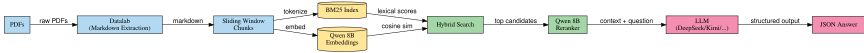

In [ ]:
#| echo: false
#| fig-height: 6
#| out-width: "100%"
import graphviz

d = graphviz.Digraph('WattBot', format='png')
d.attr(rankdir='LR', size='12,10', fontsize='16', fontname='Helvetica')
d.attr('edge', fontsize='14', fontname='Helvetica')

with d.subgraph(name='cluster_prep') as prep:
    prep.attr(label='Data Preparation', style='rounded', fillcolor='#E8F4FD', color='#4A90D9')
    d.node('pdf', 'PDFs', shape='box', style='filled', fillcolor='#B3D9F2')
    d.node('dl', 'Datalab\n(Markdown Extraction)', shape='box', style='filled', fillcolor='#B3D9F2')
    d.node('chunk', 'Sliding Window\nChunks', shape='box', style='filled', fillcolor='#B3D9F2')
    d.edge('pdf', 'dl', label='raw PDFs')
    d.edge('dl', 'chunk', label='markdown')

with d.subgraph(name='cluster_index') as idx:
    idx.attr(label='Indexing', style='rounded', fillcolor='#FFF8E1', color='#F5A623')
    d.node('bm25', 'BM25 Index', shape='cylinder', style='filled', fillcolor='#FFE699')
    d.node('emb', 'Qwen 8B\nEmbeddings', shape='cylinder', style='filled', fillcolor='#FFE699')
    d.edge('chunk', 'bm25', label='tokenize')
    d.edge('chunk', 'emb', label='embed')

with d.subgraph(name='cluster_retrieval') as ret:
    ret.attr(label='Retrieval', style='rounded', fillcolor='#F0FFF0', color='#4CAF50')
    d.node('hybrid', 'Hybrid Search', shape='box', style='filled', fillcolor='#A5D6A7')
    d.node('rerank', 'Qwen 8B\nReranker', shape='box', style='filled', fillcolor='#A5D6A7')
    d.edge('bm25', 'hybrid', label='lexical scores')
    d.edge('emb', 'hybrid', label='cosine sim')
    d.edge('hybrid', 'rerank', label='top candidates')

with d.subgraph(name='cluster_gen') as gen:
    gen.attr(label='Generation', style='rounded', fillcolor='#FCE4EC', color='#E91E63')
    d.node('llm', 'LLM\n(DeepSeek/Kimi/...)', shape='box', style='filled', fillcolor='#F48FB1')
    d.node('out', 'JSON Answer', shape='box', style='filled', fillcolor='#F48FB1')
    d.edge('rerank', 'llm', label='context + question')
    d.edge('llm', 'out', label='structured output')

d
